### **REGRESSION AND CORRELATION ANALYSIS**

#### **Correlational Analysis**

##### **Load All the Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Filter warnings to avoid cluttering the output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style (equivalent to ggplot2 theme)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


##### **Load the Mtcars Dataset**

In [2]:
url_mtcars = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/mtcars.csv"
mtcars = pd.read_csv(url_mtcars, index_col=0)
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


##### **Basic Data Exploration**

In [3]:
mtcars.info()

<class 'pandas.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


##### **Scatter Plot of Miles per Gallon and Weight of the Car**

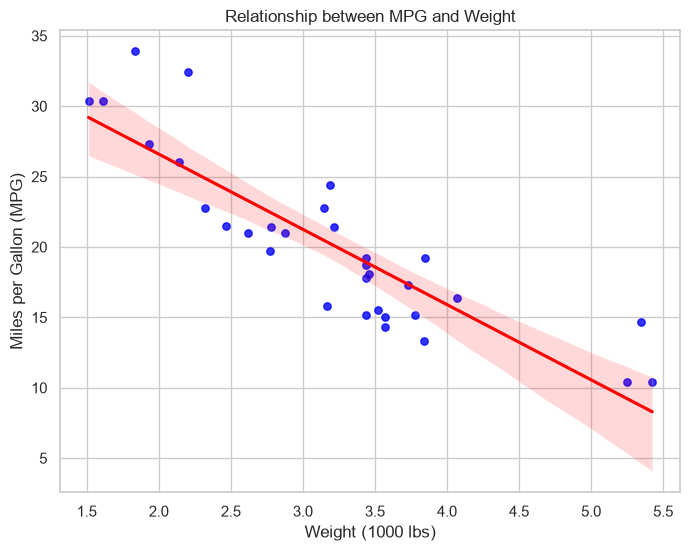

In [4]:
plt.figure(figsize=(8, 6))
sns.regplot(x='wt', y='mpg', data=mtcars,
            scatter_kws={'color': 'blue', 's': 28},
            line_kws={'color': 'red'})
plt.title('Relationship between MPG and Weight')
plt.xlabel('Weight (1000 lbs)')
plt.ylabel('Miles per Gallon (MPG)')
plt.show()

##### **Null and Alternative Hypotheses**
- Null: There is no correlational association between mpg and weight; there is zero correlation
- Alternative: There is a correlational association between mpg and weight

##### **Pearson's Correlational Analysis(Parametric Test)**

In [5]:
r_pearson, p_pearson = stats.pearsonr(mtcars['wt'], mtcars['mpg'])
print(f"Pearson correlation coefficient: {r_pearson:.4f}, P-value: {p_pearson:.2e}")

Pearson correlation coefficient: -0.8677, P-value: 1.29e-10


##### **Spearman's Rank-Order Correlation(Non-Parametric Test)**

In [6]:
r_spearman, p_spearman = stats.spearmanr(mtcars['wt'], mtcars['mpg'])
print(f"Spearman Rank-Order Correlation: {r_spearman:.4f}, P-value: {p_spearman:.2e}")

Spearman Rank-Order Correlation: -0.8864, P-value: 1.49e-11


##### **CORRELATIONAL MATRIX**

In [7]:
num_vars = mtcars[['mpg', 'cyl', 'disp', 'hp', 'wt']]

In [8]:
corr_matrix = num_vars.corr(method='pearson')
display(corr_matrix.round(3))

,mpg,cyl,disp,hp,wt
mpg,1.000,-0.852,-0.848,-0.776,-0.868
cyl,-0.852,1.000,0.902,0.832,0.782
disp,-0.848,0.902,1.000,0.791,0.888
hp,-0.776,0.832,0.791,1.000,0.659
wt,-0.868,0.782,0.888,0.659,1.000


##### **Visualize Correlational Results**

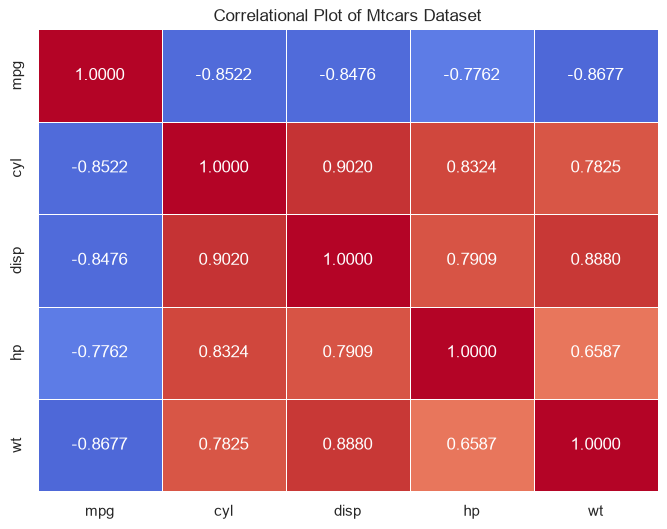

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt='.4f',
            linewidths=0.5,
            cbar = False,
            center=0)
plt.title('Correlational Plot of Mtcars Dataset')
plt.show()

#### **SIMPLE LINEAR REGRESSION MODEL**

In [10]:
model_slr = smf.ols('mpg ~ wt', data=mtcars).fit()
print(model_slr.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     91.38
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.29e-10
Time:                        21:00:31   Log-Likelihood:                -80.015
No. Observations:                  32   AIC:                             164.0
Df Residuals:                      30   BIC:                             167.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.2851      1.878     19.858      0.0

Here is a simple interpretation:

- The regression examines the relationship between mpg (miles per gallon) and wt (car weight).
- The R-squared is 0.753, meaning that about 75.3% of the variation in mpg is explained by car weight.
- The coefficient for wt is -5.3445. This means that, on average, a one-unit increase in car weight is associated with a decrease of about 5.34 mpg.
- The relationship is statistically significant because the p-value for wt is 0.000, which is less than 0.05.
- The overall model is also statistically significant (F-statistic = 91.38, p < 0.001).
- The intercept is 37.2851, meaning the predicted mpg would be about 37.29 when weight is zero, although this has little practical meaning.
- The Durbin-Watson value of 1.252 suggests there may be some positive autocorrelation in the residuals.
- The Jarque-Bera p-value of 0.301 indicates that there is no strong evidence that the residuals are non-normal.

Overall: The results show a strong and statistically significant negative relationship between car weight and fuel efficiency: heavier cars tend to have lower mpg

In [11]:
df = pd.read_csv('income.csv')
df.head()

,Year,Income,Consumption
0,1950.0,791.8,733.2
1,1951.0,819.0,748.7
2,1952.0,844.3,771.4
3,1953.0,880.0,802.5
4,1954.0,894.0,822.7


In [12]:
model_slr = smf.ols('Consumption ~ Income', data=df).fit()
print(model_slr.summary())

                            OLS Regression Results                            
Dep. Variable:            Consumption   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.359e+04
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           6.61e-50
Time:                        21:00:31   Log-Likelihood:                -155.71
No. Observations:                  36   AIC:                             315.4
Df Residuals:                      34   BIC:                             318.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.3737      9.629      1.181      0.2

#### **MULTIPLE LINEAR REGRESSION ANALYSIS**

In [13]:
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [14]:
model_slr = smf.ols('mpg ~ wt+hp', data=mtcars).fit()
print(model_slr.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     69.21
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           9.11e-12
Time:                        21:00:32   Log-Likelihood:                -74.326
No. Observations:                  32   AIC:                             154.7
Df Residuals:                      29   BIC:                             159.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.2273      1.599     23.285      0.0

**Predictors**
* Weight of the vehicle
* Horse Power

**Predicted Variable**
* Miles Per Gallon

##### **Prediction**

**Predicted MPG:** $\hat{\text{MPG}} = 37.227 - (3.678 \times 2.20) - (0.032 \times 110)$

#### **Model Diagnostics**

#### **Multicolinearity and Ifluential Observations**
* **VIF(Variance Inflation Factor):** Values > 5 or 10 indicates high multicolinearity
* **Cook's Distance:** Identifies influential observations.Threshold commonly set at 4/6

##### **1. Multicolinearity**

In [15]:
x_vif = mtcars[['wt', 'hp']].copy()
x_vif['compiled'] = 1  # Add a constant term for VIF calculation
vif_data = pd.DataFrame()
vif_data['feature'] = x_vif.columns
vif_data['VIF'] = [variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])]
display(vif_data)

,feature,VIF
0,wt,1.766625
1,hp,1.766625
2,compiled,12.161539


##### **2. Cook's Distance and Influential Observations**

In [16]:
influence = model_slr.get_influence()
cooks_d = influence.cooks_distance[0]
mtcars['cooks_d'] = cooks_d
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,cooks_d
rownames,,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,0.015897
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,0.005465
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,0.020707
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,0.000047
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,0.000274


In [17]:
mtcars.info()

<class 'pandas.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   mpg      32 non-null     float64
 1   cyl      32 non-null     int64  
 2   disp     32 non-null     float64
 3   hp       32 non-null     int64  
 4   drat     32 non-null     float64
 5   wt       32 non-null     float64
 6   qsec     32 non-null     float64
 7   vs       32 non-null     int64  
 8   am       32 non-null     int64  
 9   gear     32 non-null     int64  
 10  carb     32 non-null     int64  
 11  cooks_d  32 non-null     float64
dtypes: float64(6), int64(6)
memory usage: 4.3+ KB


In [18]:
threshold = 4 / len(mtcars)
threshold

0.125

In [19]:
influential_obs = mtcars[mtcars['cooks_d'] > threshold]. index
print(f"\nInfluential observations (Cook's D > {threshold:.4f}): {influential_obs.to_list()}")


Influential observations (Cook's D > 0.1250): ['Chrysler Imperial', 'Fiat 128', 'Toyota Corolla', 'Maserati Bora']


#### **Re-Estimate the Model Without Influential Observations**

In [20]:
mtcars_no_inf = mtcars.drop(influential_obs)
model_slr2 = smf.ols('mpg ~ wt+hp', data=mtcars_no_inf).fit()
print(model_slr2.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     102.9
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           8.60e-13
Time:                        21:00:32   Log-Likelihood:                -54.076
No. Observations:                  28   AIC:                             114.2
Df Residuals:                      25   BIC:                             118.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.3375      1.255     28.956      0.0

##### **Prediction using the newly estimated model**

**Predicted MPG:** $\hat{\text{MPG}} = 36.3375 - (3.7517 \times 2.620) - (0.0332 \times 110)$

**Predicted MPG:** $ = 22.856 $

**Observed MPG:** $ = 21.000 $

**Residual:** $ =21.00 - 23.54664 = -1.856 $

##### **Testing the Assumptions of Classical Linear Regression Model**

1. **Normality of the Residuals:** Shapiro Wilks Test and Anderson-Darling Test
2. **Homoscedasticity:** The constant variance of the residuals/ error term; Breusch Pagan Test
3. **Independence of the Residuals/Autocorrelation Test:** Durbin Watson Test

In [21]:
residuals = model_slr2.resid
residuals

rownames
Mazda RX4             -1.851752
Mazda RX4 Wag         -0.895060
Datsun 710            -1.742322
Hornet 4 Drive         0.780530
Hornet Sportabout      1.085155
Valiant               -1.766486
Duster 360            -0.500444
Merc 240D              2.091302
Merc 230               1.438094
Merc 280              -0.143233
Merc 280C             -1.543233
Merc 450SE             1.314939
Merc 450SL             0.939349
Merc 450SLC           -0.973064
Cadillac Fleetwood     0.572941
Lincoln Continental    1.558125
Honda Civic            1.849938
Toyota Corona         -2.365368
Dodge Challenger      -2.645662
AMC Javelin           -3.264559
Camaro Z28            -0.487475
Pontiac Firebird       3.104607
Fiat X1-9              0.415828
Porsche 914-2          0.715889
Lotus Europa           3.494792
Ford Pantera L         0.130389
Ferrari Dino          -0.428507
Volvo 142E            -0.884713
dtype: float64

##### **1. Normality Test**

* Null hypothesis: Residuals follow a normal distribution
* Alternative hypothesis: Residuals deviate from a normal distribution

##### **Decision Criteria**
> **Reject** the null hypothesis if and only if the p-value < 0.05

In [22]:
#Shapiro Wilks Test
stat_sw, p_sw = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: W = {stat_sw:.4f}, p-value = {p_sw:.5f}")

Shapiro-Wilk Test: W = 0.9871, p-value = 0.97385


From the results above, we fail to reject the null hypothesis of the Shapiro-Wilk test, indicating that the residuals are normally distributed.

In [23]:
# Anderson-Darling Test
stat_ad,crit_ad, sig_ad = stats.anderson(residuals, dist='norm')
print(f"Anderson-Darling Test: W = {stat_ad:.5f}")

Anderson-Darling Test: W = 0.13549


##### **Q-Q Plot and Histogram for Distribution of Residuals**

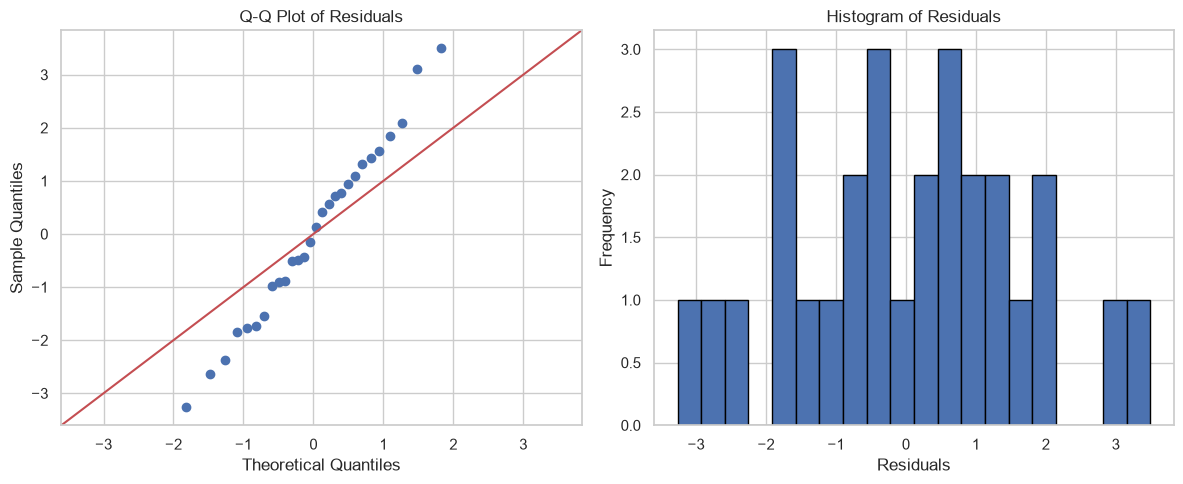

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot
sm.qqplot(residuals, line='45', ax=ax[0])
ax[0].set_title('Q-Q Plot of Residuals')

# Histogram of residuals
ax[1].hist(residuals, bins=20, edgecolor='black')
ax[1].set_title('Histogram of Residuals')
ax[1].set_xlabel('Residuals')
ax[1].set_ylabel('Frequency')   

plt.tight_layout()
plt.show()

##### **2. Homoscedasticity: Breusch Pagan Test**

**Null Hypothesis:** There is a constant variance of the residuals (preferred decision)

**Alternative Hypothsis:** The variace of the residuals is non-constant (unwanted decision)

In [25]:
bp_test = het_breuschpagan(residuals, model_slr2.model.exog)
print(f"\nBreusch-Pagan Test: BP = {bp_test[0]:.5f}, p-value = {bp_test[1]:.5f}")


Breusch-Pagan Test: BP = 1.34296, p-value = 0.51095


##### **3. Independence of the Residuals: Durbin Watson**

In [26]:
dw_test = durbin_watson(residuals)
print(f"\nDurbin-Watson Test: DW = {dw_test:.5f}")


Durbin-Watson Test: DW = 1.41731
